In [15]:
# import libraries
import os, sys
import matplotlib.pyplot as plt

# --- Configuration ---
from ICESEE.config._utility_imports import *
from ICESEE.src.utils.tools import icesee_savefig

In [16]:
data_dir='_modelrun_datasets'

In [17]:
filter_type = "true-wrong"
model_name = "lorenz"
file_path = f"results/{filter_type}-{model_name}.h5"
datasets_tw = extract_datasets_from_h5(file_path)
t=datasets_tw['t']
ind_m = datasets_tw['obs_index']
tm_m = datasets_tw['obs_max_time'][0]
run_mode = datasets_tw['run_mode'][0]
t.shape

[ICESEE] Reading data from results/true-wrong-lorenz.h5...
[ICESEE] Dataset 'Lxy' extracted with shape (2,)
[ICESEE] Dataset 'b_io' extracted with shape (2,)
[ICESEE] Dataset 'nxy' extracted with shape (2,)
[ICESEE] Dataset 'obs_index' extracted with shape (10,)
[ICESEE] Dataset 'obs_max_time' extracted with shape (1,)
[ICESEE] Dataset 'run_mode' extracted with shape (1,)
[ICESEE] Dataset 't' extracted with shape (1001,)
[ICESEE] Data extraction complete.


(1001,)

In [18]:
filter_type = "EnTKF" # "EnKF", "DEnKF", "EnTKF", "EnRSKF"
if run_mode != 0:
    file_path = f"{results_dir}/{filter_type}-{model_name}.h5"
    datasets = extract_datasets_from_h5(file_path)
    ensemble_vec_full = datasets["ensemble_vec_full"]
    ensemble_vec_mean = datasets["ensemble_vec_mean"] 
    ensemble_bg       = datasets["ensemble_bg"]
else:
    # file_path = '_modelrun_datasets/icesee_ensemble_data.h5'
    file_path = f'{data_dir}/icesee_ensemble_data.h5'
    import h5py
    with h5py.File(file_path, 'r') as f:
        ensemble_vec_full = f['ensemble'][:]
        ensemble_vec_mean = f['ensemble_mean'][:]
        # ensemble_true_state = f['true_state'][:]
        # ensemble_nurged_state = f['nurged_state'][:]
        ensemble_bg = None

# file_path='_modelrun_datasets/true_nurged_states.h5'
with h5py.File(f'{data_dir}/true_nurged_states.h5', 'r') as f:
    ensemble_true_state = f['true_state'][:]
    ensemble_nurged_state = f['nurged_state'][:]

with h5py.File(f'{data_dir}/synthetic_obs.h5','r') as f:
    w = f['hu_obs'][:]
     # print(f["true_state"])

In [19]:
ensemble_true_state.shape
# t.shape
# 10/0.01

(3, 1001)

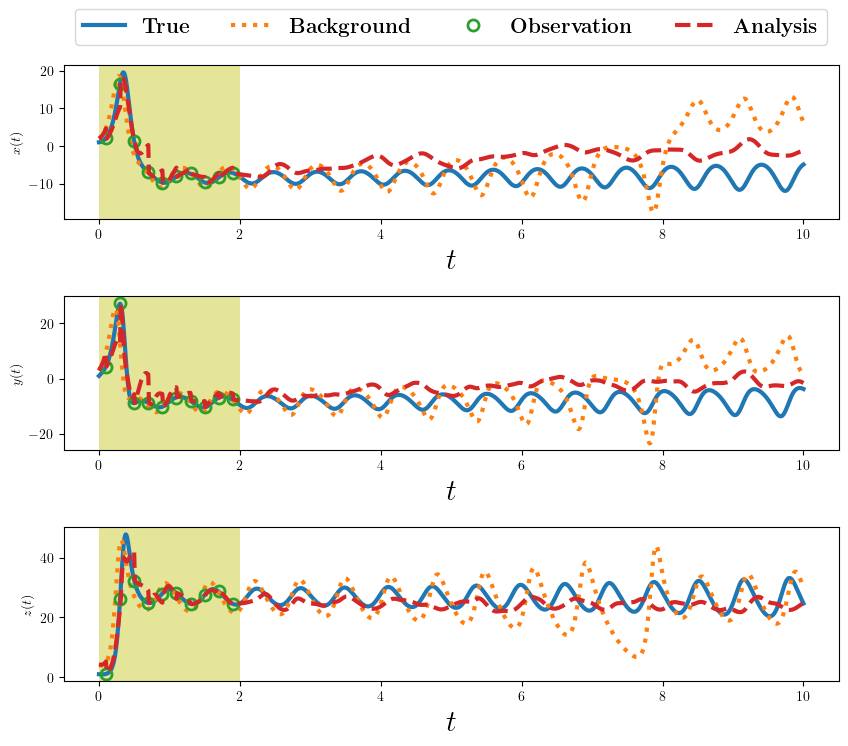

In [ ]:
import shutil
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

# --- LaTeX only if available (GHUB-safe) ---
mpl.rcParams["text.usetex"] = bool(shutil.which("latex"))

# Fallback fonts when LaTeX is unavailable
mpl.rcParams["mathtext.fontset"] = "dejavusans"
mpl.rcParams["font.family"] = "DejaVu Sans"

# Your font choices (works either way)
font = {"family": "normal", "weight": "bold", "size": 14}
mpl.rc("font", **font)

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 8))
ax = ax.flat

for k in range(3):
    ax[k].plot(t, ensemble_true_state[k, :], label="True", linewidth=3)
    ax[k].plot(t, ensemble_nurged_state[k, :], ":", label="Background", linewidth=3)
    ax[k].plot(t[ind_m], w[k, :], "o", fillstyle="none",
               label="Observation", markersize=8, markeredgewidth=2)
    ax[k].plot(t, ensemble_vec_mean[k, :], "--", label="Analysis", linewidth=3)
    ax[k].set_xlabel(r"$t$", fontsize=22)
    ax[k].axvspan(0, tm_m, alpha=0.4, lw=0)

ax[0].legend(loc="center", bbox_to_anchor=(0.5, 1.25), ncol=4, fontsize=15)
ax[0].set_ylabel(r"$x(t)$")
ax[1].set_ylabel(r"$y(t)$")
ax[2].set_ylabel(r"$z(t)$")
fig.subplots_adjust(hspace=0.5)

# --- Save figure where wrapper expects it ---
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/results.png", dpi=200, bbox_inches="tight")
plt.show()

In [21]:
all_flters = False
if all_flters:
    filter_types = ["EnKF", "DEnKF", "EnTKF", "EnRSKF"]

    # Prepare data for dynamic subplot layout
    available_filters = []
    datasets_dict = {}

    for filter_type in filter_types:
        file_path = f"results/{filter_type}-{model_name}.h5"
        try:
            datasets = extract_datasets_from_h5(file_path)
            datasets_dict[filter_type] = datasets
            available_filters.append(filter_type)  # Keep track of filters with data
        except FileNotFoundError:
            print(f"Warning: Dataset for {filter_type} not found. Skipping.")
        except KeyError as e:
            print(f"Warning: Missing dataset key {e} in {filter_type}. Skipping.")

    # Dynamic layout based on available filters
    ncols = len(available_filters)
    if ncols == 0:
        raise ValueError("No datasets available for any filter type!")

    # Dynamically adjust figsize to maintain aspect ratio
    base_width = 5
    base_height = 3  # Base height per subplot row
    fig_width = max(base_width * ncols, 10)  # Ensure minimum width for clarity
    fig_height = base_height * 3  # 3 rows for x(t), y(t), z(t)

    fig, axs = plt.subplots(nrows=3, ncols=ncols, figsize=(fig_width, fig_height), sharex=True)

    # If there's only one column, ensure axs is 2D
    if ncols == 1:
        axs = np.expand_dims(axs, axis=1)

    # Colors and line styles
    styles = {
        "True": {"color": "blue", "linewidth": 2, "label": r'\bf{True}'},
        "Background": {"color": "orange", "linestyle": ":", "linewidth": 2, "label": r'\bf{Background}'},
        "Observation": {"color": "green", "marker": "o", "linestyle": "none", "fillstyle": "none", "markersize": 6, "markeredgewidth": 1.5, "label": r'\bf{Observation}'},
        "Analysis": {"color": "red", "linestyle": "--", "linewidth": 2, "label": r'\bf{Analysis}'},
    }

    # Define the y-axis limits for each variable
    y_limits = [(-20, 25), (-25, 30), (-5, 50)]  # Adjust these to reflect realistic bounds

    # Plot the available datasets
    for i, filter_type in enumerate(available_filters):
        datasets = datasets_dict[filter_type]

        # Extract datasets based on filter type
        statevec_ens_full = datasets["statevec_ens_full"]
        statevec_ens_mean = datasets["statevec_ens_mean"]
        statevec_bg = datasets["statevec_bg"]

        # Plot each variable (x, y, z) in separate rows
        for k in range(3):
            ax = axs[k, i]
            ax.plot(t, statevec_true[k, :], **styles["True"])
            ax.plot(t, statevec_bg[k, :], **styles["Background"])
            ax.plot(t[ind_m], w[k, :], **styles["Observation"])
            ax.plot(t, statevec_ens_mean[k, :], **styles["Analysis"])

            if k == 2:  # Only set x-axis labels for the bottom row
                ax.set_xlabel(r'$t$', fontsize=16)
            if i == 0:  # Only set y-axis labels for the first column
                ax.set_ylabel([r'$x(t)$', r'$y(t)$', r'$z(t)$'][k], fontsize=16)

            # Set independent y-axis limits
            ax.set_ylim(y_limits[k])

            # Highlight a region of interest
            ax.axvspan(0, tm_m, color='y', alpha=0.2, lw=0)

            # Add the filter type as the title for each column
            if k == 0:
                ax.set_title(filter_type, fontsize=18, weight='bold')

            # Add gridlines
            ax.grid(True, linestyle="--", alpha=0.5)

    # Add a single legend inside the plot grid
    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize=14)

    # Adjust subplot spacing
    fig.subplots_adjust(hspace=0.3, wspace=0.3)

    # Automatically adjust layout to minimize whitespace
    plt.tight_layout()

    # Show the plot
    plt.show()
    